# Ordinary Least Square

In [ ]:
import pandas as pd

data = {'year': [2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2016,2016,2016,2016,2016,2016,2016,2016,2016,2016,2016,2016],
        'month': [12,11,10,9,8,7,6,5,4,3,2,1,12,11,10,9,8,7,6,5,4,3,2,1],
        'interest_rate': [2.75,2.5,2.5,2.5,2.5,2.5,2.5,2.25,2.25,2.25,2,2,2,1.75,1.75,1.75,1.75,1.75,1.75,1.75,1.75,1.75,1.75,1.75],
        'unemployment_rate': [5.3,5.3,5.3,5.3,5.4,5.6,5.5,5.5,5.5,5.6,5.7,5.9,6,5.9,5.8,6.1,6.2,6.1,6.1,6.1,5.9,6.2,6.2,6.1],
        'index_price': [1464,1394,1357,1293,1256,1254,1234,1195,1159,1167,1130,1075,1047,965,943,958,971,949,884,866,876,822,704,719]
        }

df = pd.DataFrame(data)

display(df)

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256
5,2017,7,2.50,5.6,1254
6,2017,6,2.50,5.5,1234
7,2017,5,2.25,5.5,1195
8,2017,4,2.25,5.5,1159
9,2017,3,2.25,5.6,1167


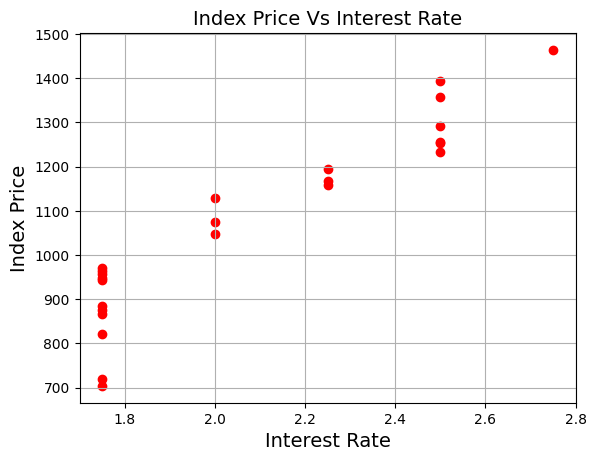

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['interest_rate'], df['index_price'], color='red')
plt.title('Index Price Vs Interest Rate', fontsize=14)
plt.xlabel('Interest Rate', fontsize=14)
plt.ylabel('Index Price', fontsize=14)
plt.grid(True)
plt.show()

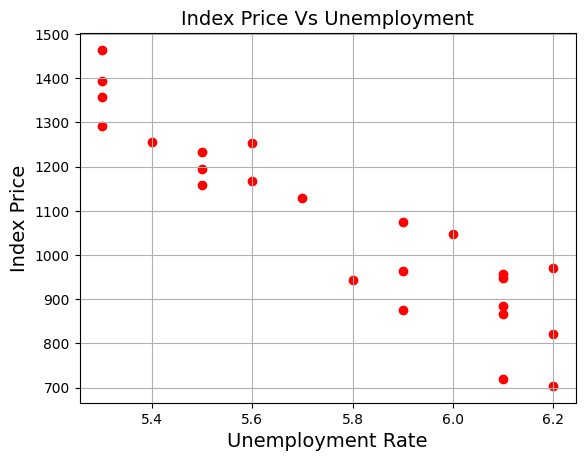

In [ ]:
plt.scatter(df['unemployment_rate'], df['index_price'], color='red')
plt.title('Index Price Vs Unemployment', fontsize=14)
plt.xlabel('Unemployment Rate', fontsize=14)
plt.ylabel('Index Price', fontsize=14)
plt.grid(True)
plt.show()

### Model
$index\_price =  c_1interest\_rate+c_2unemployment\_rate + c_3$

In [ ]:
import numpy as np

A = df[['interest_rate','unemployment_rate']].assign(offset=1).values
A

array([[2.75, 5.3 , 1.  ],
       [2.5 , 5.3 , 1.  ],
       [2.5 , 5.3 , 1.  ],
       [2.5 , 5.3 , 1.  ],
       [2.5 , 5.4 , 1.  ],
       [2.5 , 5.6 , 1.  ],
       [2.5 , 5.5 , 1.  ],
       [2.25, 5.5 , 1.  ],
       [2.25, 5.5 , 1.  ],
       [2.25, 5.6 , 1.  ],
       [2.  , 5.7 , 1.  ],
       [2.  , 5.9 , 1.  ],
       [2.  , 6.  , 1.  ],
       [1.75, 5.9 , 1.  ],
       [1.75, 5.8 , 1.  ],
       [1.75, 6.1 , 1.  ],
       [1.75, 6.2 , 1.  ],
       [1.75, 6.1 , 1.  ],
       [1.75, 6.1 , 1.  ],
       [1.75, 6.1 , 1.  ],
       [1.75, 5.9 , 1.  ],
       [1.75, 6.2 , 1.  ],
       [1.75, 6.2 , 1.  ],
       [1.75, 6.1 , 1.  ]])

In [ ]:
Y = df['index_price'].values.reshape(-1,1)
Y

array([[1464],
       [1394],
       [1357],
       [1293],
       [1256],
       [1254],
       [1234],
       [1195],
       [1159],
       [1167],
       [1130],
       [1075],
       [1047],
       [ 965],
       [ 943],
       [ 958],
       [ 971],
       [ 949],
       [ 884],
       [ 866],
       [ 876],
       [ 822],
       [ 704],
       [ 719]])

## Pseudoinverse

In [ ]:
B = (np.linalg.inv(A.T @ A) @ A.T) @ Y
B

array([[ 345.54008701],
       [-250.14657137],
       [1798.40397762]])

## Verify the result with statmodels

In [ ]:
from statsmodels.regression.linear_model import OLS

lm = OLS(endog=Y, exog = A).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     92.07
Date:                Wed, 14 Aug 2024   Prob (F-statistic):           4.04e-11
Time:                        08:51:22   Log-Likelihood:                -134.61
No. Observations:                  24   AIC:                             275.2
Df Residuals:                      21   BIC:                             278.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           345.5401    111.367      3.103      0.005     113.940     577.140
x2          -250.1466    117.950     -2.121      0.046    -495.437      -4.856
const       1798.4040    899.248      2.000      0.059     -71.685    3668.493
==============================================================================
Omnibus:                        2.691   Durbin-Watson:                   0.530
Prob(Omnibus):                  0.260   Jarque-Bera (JB):                1.551
Skew:                          -0.612   Prob(JB):                        0.461
Kurtosis:                       3.226   Cond. No.                         394.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Iterative approach
Ref: https://medium.com/@IwriteDSblog/gradient-descent-for-logistics-regression-in-python-18e033775082

# Functions for preparation

In [ ]:
def generateXvector(X):
    """ Taking the original independent variables matrix and add a row of 1 which corresponds to x_0
        Parameters:
          X:  independent variables matrix
        Return value: the matrix that contains all the values in the dataset, not include the outcomes variables.
    """
    vectorX = np.c_[np.ones((len(X), 1)), X]
    return vectorX

In [ ]:
def theta_init(X):
    """ Generate an initial value of vector θ from the original independent variables matrix
         Parameters:
          X:  independent variables matrix
        Return value: a vector of theta filled with initial guess
    """
    theta = np.random.randn(len(X[0])+1, 1)
    return theta

In [ ]:
import math
def sigmoid_function(X):
    """ Calculate the sigmoid value of the inputs
         Parameters:
          X:  values
        Return value: the sigmoid value
    """
    return 1/(1+math.e**(-X))

## Learning logistic regression model

In [ ]:
def Logistics_Regression(X,y,learningrate, iterations):
    """ Find the Logistics regression model for the data set
         Parameters:
          X: independent variables matrix
          y: dependent variables matrix
          learningrate: learningrate of Gradient Descent
          iterations: the number of iterations
        Return value: the final theta vector and the plot of cost function
    """
    y_new = np.reshape(y, (len(y), 1))
    cost_lst = []
    vectorX = generateXvector(X)
    theta = theta_init(X)
    m = len(X)
    for i in range(iterations):
        gradients = 2/m * vectorX.T.dot(sigmoid_function(vectorX.dot(theta)) - y_new)
        theta = theta - learningrate * gradients
        y_pred = sigmoid_function(vectorX.dot(theta))
        cost_value = - np.sum(np.dot(y_new.T,np.log(y_pred)+ np.dot((1-y_new).T,np.log(1-y_pred)))) /(len(y_pred))
 #Calculate the loss for each training instance
        cost_lst.append(cost_value)
    plt.plot(np.arange(1,iterations),cost_lst[1:], color = 'red')
    plt.title('Cost function Graph')
    plt.xlabel('Number of iterations')
    plt.ylabel('Cost')
    return theta

In [ ]:
from sklearn import datasets
iris = datasets.load_iris()
X = iris["data"]
y = (iris["target"] == 0).astype(np.int64) #return 1 if Iris Versicolor, else 0.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
X_train

array([[ 0.61303014,  0.10850105,  0.94751783,  0.736072  ],
       [-0.56776627, -0.12400121,  0.38491447,  0.34752959],
       [-0.80392556,  1.03851009, -1.30289562, -1.33615415],
       [ 0.25879121, -0.12400121,  0.60995581,  0.736072  ],
       [ 0.61303014, -0.58900572,  1.00377816,  1.25412853],
       [-0.80392556, -0.82150798,  0.04735245,  0.21801546],
       [-0.21352735,  1.73601687, -1.19037495, -1.20664002],
       [ 0.14071157, -0.82150798,  0.72247648,  0.47704373],
       [ 0.02263193, -0.12400121,  0.21613346,  0.34752959],
       [-0.09544771, -1.05401024,  0.10361279, -0.04101281],
       [ 1.0853487 , -0.12400121,  0.94751783,  1.1246144 ],
       [-1.39432376,  0.34100331, -1.41541629, -1.33615415],
       [ 1.20342834,  0.10850105,  0.72247648,  1.38364267],
       [-1.04008484,  1.03851009, -1.24663528, -0.81809761],
       [-0.56776627,  1.50351461, -1.30289562, -1.33615415],
       [-1.04008484, -2.4490238 , -0.1776889 , -0.30004108],
       [ 0.73110978, -0.

In [ ]:
y_train

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1])

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0, penalty = 'none')
classifier.fit(X_train, y_train)
classifier.intercept_, classifier.coef_

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


(array([-11.07402312]),
 array([[ -1.32289075,   4.23503694, -10.11887281,  -9.22137322]]))

In [ ]:
y_pred = classifier.predict(X_test)
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy_score(y_test, y_pred)

1.0

In [ ]:
def column(matrix, i):
    """ Returning all the values in a specific columns
         Parameters:
          X: the input matrix
          i: the column
     Return value: an array with desired column
    """
    return [row[i] for row in matrix]

def accuracy_LR(X,y,learningrate, iteration,X_test, y_test):
    """ Returning the accuracy score for a training model

    """
    ideal = Logistics_Regression(X,y,learningrate, iteration)
    hypo_line = ideal[0]
    for i in range(1,len(ideal)):
        hypo_line = hypo_line + ideal[i]*column(X_test,i-1)
    logistic_function = sigmoid_function(hypo_line)
    for i in range(len(logistic_function)):
        if logistic_function[i] >= 0.5:
            logistic_function[i] = 1
        else:
            logistic_function[i] = 0
    last1 = np.concatenate((logistic_function.reshape(len(logistic_function),1), y_test.reshape(len(y_test),1)),1)
    count = 0
    for i in range(len(y_test)):
        if last1[i][0] == last1[i][1]:
            count = count+1
    acc = count/(len(y_test))
    return acc

array([[-4.19354092],
       [-0.93250245],
       [ 2.58379539],
       [-5.23355041],
       [-2.77261367]])

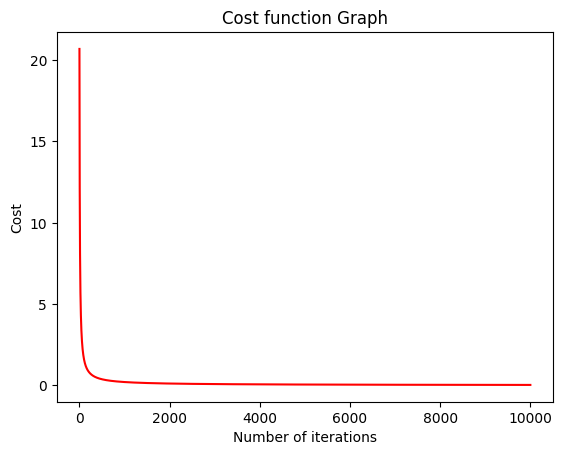

In [ ]:
Logistics_Regression(X_train,y_train, 0.1, 10000)

1.0

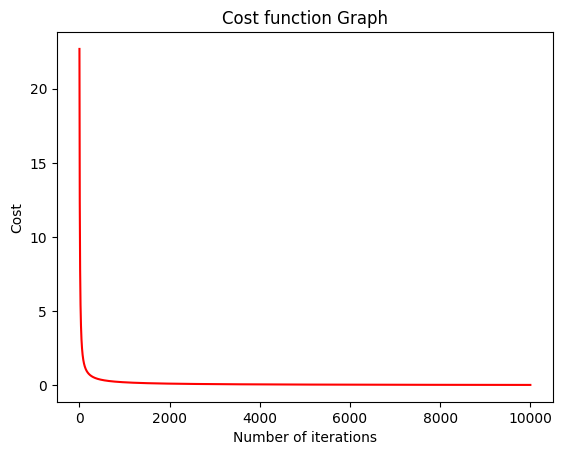

In [ ]:
accuracy_LR(X_train,y_train, 0.1, 10000,X_test, y_test)